# Developer Market Trends & Salary Drivers
## Phase 3: Modeling (Simple & Multiple Linear Regression)

### What I did in this notebook
I built two models to predict developer pay. Both are Linear Regression.

### Research question
RQ3: How do country, experience, education, job type, and remote work affect pay?

### Key decisions
- Target: `ConvertedCompYearly_log` (log of yearly pay).
- Data: I only used rows with reported pay, and I removed outliers.
- I dropped `Age_num` and kept `WorkExp` - the two are highly correlated (r = 0.85).

### Input
The notebook load `data/survey_data_eda_ready.csv` from Phase 2.


### 1. Load Data


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns', None)

DATA_DIR = '../data'
df = pd.read_csv(f'{DATA_DIR}/survey_data_eda_ready.csv')

print(f"Loaded {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Loaded 65437 rows x 40 columns


,ResponseId,Country,EdLevel,Employment,RemoteWork,CodingActivities,YearsCodePro,CompTotal,ConvertedCompYearly,Country_clean,EdLevel_clean,"Employed, full-time","Employed, part-time",I prefer not to say,"Independent contractor, freelancer, or self-employed","Not employed, and not looking for work","Not employed, but looking for work",Retired,"Student, full-time","Student, part-time",has_compensation_data,YearsCodePro_num,ExperienceLevel,ConvertedCompYearly_log,ConvertedCompYearly_MinMax,ConvertedCompYearly_Zscore,Age,RemoteWork_raw,CodingActivities_raw,DevType,LanguageHaveWorkedWith,LanguageWantToWorkWith,WorkExp,Industry,JobSatPoints_1,JobSat,RemoteWork_imputed,CodingActivities_imputed,is_comp_outlier,Age_num
0,1,United States of America,Primary/elementary school,"Employed, full-time",Remote,Hobby,NaN,NaN,NaN,United States of America,Primary school,1,0,0,0,0,0,0,0,0,False,NaN,NaN,NaN,NaN,NaN,Under 18 years old,Remote,Hobby,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,16.0
1,2,United Kingdom of Great Britain and Northern I...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,17,NaN,NaN,United Kingdom,Bachelor's degree,1,0,0,0,0,0,0,0,0,False,17.0,Senior,NaN,NaN,NaN,35-44 years old,Remote,Hobby;Contribute to open-source projects;Other...,"Developer, full-stack",Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,17.0,NaN,0.0,NaN,False,False,False,40.0
2,3,United Kingdom of Great Britain and Northern I...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Employed, full-time",Remote,Hobby;Contribute to open-source projects;Other...,27,NaN,NaN,United Kingdom,Master's degree,1,0,0,0,0,0,0,0,0,False,27.0,Senior,NaN,NaN,NaN,45-54 years old,Remote,Hobby;Contribute to open-source projects;Other...,Developer Experience,C#,C#,NaN,NaN,NaN,NaN,False,False,False,50.0
3,4,Canada,Some college/university study without earning ...,"Student, full-time","Hybrid (some remote, some in-person)",Hobby,NaN,NaN,NaN,Canada,"Some college, no degree",0,0,0,0,0,0,0,1,0,False,NaN,NaN,NaN,NaN,NaN,18-24 years old,NaN,NaN,"Developer, full-stack",C;C++;HTML/CSS;Java;JavaScript;PHP;PowerShell;...,HTML/CSS;Java;JavaScript;PowerShell;Python;SQL...,NaN,NaN,NaN,NaN,True,True,False,21.0
4,5,Norway,"Secondary school (e.g. American high school, G...","Student, full-time","Hybrid (some remote, some in-person)",Hobby,NaN,NaN,NaN,Norway,Secondary school,0,0,0,0,0,0,0,1,0,False,NaN,NaN,NaN,NaN,NaN,18-24 years old,NaN,NaN,"Developer, full-stack",C++;HTML/CSS;JavaScript;Lua;Python;Rust,C++;HTML/CSS;JavaScript;Lua;Python,NaN,NaN,NaN,NaN,True,True,False,21.0


### 2. Build the Modeling Subset
I do this in three steps:
1. Keep rows with reported pay.
2. Remove outliers.
3. Remove rows missing a needed feature.

I print how many rows are left after each step.


In [17]:
df_model = df[df['has_compensation_data']].copy()
print(f"1) has_compensation_data == True: {len(df_model)} rows")

df_model = df_model[~df_model['is_comp_outlier']].copy()
print(f"2) after excluding is_comp_outlier:  {len(df_model)} rows")

required_features = ['ExperienceLevel', 'WorkExp', 'EdLevel_clean', 'RemoteWork', 'Country_clean']
df_model = df_model.dropna(subset=required_features).copy()
print(f"3) after dropping rows missing a required feature: {len(df_model)} rows")

print(f"\nFinal modeling subset: n = {len(df_model)} "
      f"({len(df_model) / df['has_compensation_data'].sum() * 100:.1f}% of the compensation subset)")


1) has_compensation_data == True: 23435 rows
2) after excluding is_comp_outlier:  21712 rows
3) after dropping rows missing a required feature: 15011 rows

Final modeling subset: n = 15011 (64.1% of the compensation subset)


### 3. Feature Engineering
- **Country:** I one-hot encode the top 10 countries. The rest become `Other`.
- **Experience level:** I encode it as ordinal, 0 to 3.
- **Education:** one-hot encoded.
- **Job type:** already one-hot from Phase 1, I use it as-is.
- **Remote work:** one-hot encoded.
- **Work experience:** I use it as a plain number.


In [18]:
top_countries = df_model['Country_clean'].value_counts().head(10).index.tolist()
df_model['Country_grouped'] = np.where(
    df_model['Country_clean'].isin(top_countries), df_model['Country_clean'], 'Other'
)
print("Top 10 countries kept as their own category:")
print(top_countries)
print(f"\nRespondents grouped into 'Other': {(df_model['Country_grouped'] == 'Other').sum()}")


Top 10 countries kept as their own category:
['United States of America', 'Germany', 'United Kingdom', 'India', 'Ukraine', 'Canada', 'France', 'Brazil', 'Spain', 'Poland']

Respondents grouped into 'Other': 5767


In [ ]:
experience_order = {'Entry-level': 0, 
                    'Junior': 1, 
                    'Mid-level': 2, 
                    'Senior': 3}

df_model['ExperienceLevel_ordinal'] = df_model['ExperienceLevel'].map(experience_order)

df_model['ExperienceLevel_ordinal'].value_counts().sort_index()

ExperienceLevel_ordinal
0    1824
1    3396
2    4256
3    5535
Name: count, dtype: int64

In [20]:
employment_cols = [
    'Employed, full-time', 'Employed, part-time', 'I prefer not to say',
    'Independent contractor, freelancer, or self-employed',
    'Not employed, and not looking for work', 'Not employed, but looking for work',
    'Retired', 'Student, full-time', 'Student, part-time',
]

country_dummies = pd.get_dummies(df_model['Country_grouped'], prefix='Country', drop_first=True)
edlevel_dummies = pd.get_dummies(df_model['EdLevel_clean'], prefix='EdLevel', drop_first=True)
remote_dummies = pd.get_dummies(df_model['RemoteWork'], prefix='Remote', drop_first=True)

X_mlr = pd.concat([
    df_model[['WorkExp', 'ExperienceLevel_ordinal']].reset_index(drop=True),
    df_model[employment_cols].reset_index(drop=True),
    country_dummies.reset_index(drop=True),
    edlevel_dummies.reset_index(drop=True),
    remote_dummies.reset_index(drop=True),
], axis=1)

y = df_model['ConvertedCompYearly_log'].reset_index(drop=True)

print(f"Feature matrix for MLR: {X_mlr.shape[0]} rows x {X_mlr.shape[1]} columns")
X_mlr.columns.tolist()


Feature matrix for MLR: 15011 rows x 30 columns


['WorkExp',
 'ExperienceLevel_ordinal',
 'Employed, full-time',
 'Employed, part-time',
 'I prefer not to say',
 'Independent contractor, freelancer, or self-employed',
 'Not employed, and not looking for work',
 'Not employed, but looking for work',
 'Retired',
 'Student, full-time',
 'Student, part-time',
 'Country_Canada',
 'Country_France',
 'Country_Germany',
 'Country_India',
 'Country_Other',
 'Country_Poland',
 'Country_Spain',
 'Country_Ukraine',
 'Country_United Kingdom',
 'Country_United States of America',
 "EdLevel_Bachelor's degree",
 "EdLevel_Master's degree",
 'EdLevel_Other',
 'EdLevel_Primary school',
 'EdLevel_Professional/Doctoral degree',
 'EdLevel_Secondary school',
 'EdLevel_Some college, no degree',
 'Remote_In-person',
 'Remote_Remote']

### 4. Train/Test Split
I use an 80/20 split with a fixed seed. No cross-validation.


In [ ]:
X_train_mlr, X_test_mlr, y_train, y_test = train_test_split(
    X_mlr, y, test_size=0.2, random_state=42
)

X_train_slr = X_train_mlr[['WorkExp']]
X_test_slr = X_test_mlr[['WorkExp']]

print(f"Train: {X_train_mlr.shape[0]} rows | Test: {X_test_mlr.shape[0]} rows")


Train: 12008 rows | Test: 3003 rows


### 5. Model 1 - Simple Linear Regression
One input: `WorkExp`. This is my baseline.


In [22]:
slr = LinearRegression()
slr.fit(X_train_slr, y_train)

y_pred_slr = slr.predict(X_test_slr)

slr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_slr))
slr_mae = mean_absolute_error(y_test, y_pred_slr)
slr_r2 = r2_score(y_test, y_pred_slr)

print(f"SLR (WorkExp only) - log scale")
print(f"  RMSE: {slr_rmse:.4f}")
print(f"  MAE:  {slr_mae:.4f}")
print(f"  R2:   {slr_r2:.4f}")
print(f"\n  Intercept: {slr.intercept_:.4f}")
print(f"  Coefficient (WorkExp): {slr.coef_[0]:.4f}")


SLR (WorkExp only) - log scale
  RMSE: 0.7753
  MAE:  0.5985
  R2:   0.1690

  Intercept: 10.6334
  Coefficient (WorkExp): 0.0371


### 6. Model 2 - Multiple Linear Regression
I use all features from Section 3. Comparing its R² to the SLR's R² shows how much
the extra features help.


In [23]:
mlr = LinearRegression()
mlr.fit(X_train_mlr, y_train)

y_pred_mlr = mlr.predict(X_test_mlr)

mlr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlr))
mlr_mae = mean_absolute_error(y_test, y_pred_mlr)
mlr_r2 = r2_score(y_test, y_pred_mlr)

print(f"MLR (full feature set) - log scale")
print(f"  RMSE: {mlr_rmse:.4f}")
print(f"  MAE:  {mlr_mae:.4f}")
print(f"  R2:   {mlr_r2:.4f}")


MLR (full feature set) - log scale
  RMSE: 0.5788
  MAE:  0.4308
  R2:   0.5368


In [24]:
comparison = pd.DataFrame({
    'Model': ['SLR (WorkExp only)', 'MLR (full feature set)'],
    'RMSE (log scale)': [slr_rmse, mlr_rmse],
    'MAE (log scale)': [slr_mae, mlr_mae],
    'R2': [slr_r2, mlr_r2],
})
comparison


,Model,RMSE (log scale),MAE (log scale),R2
0,SLR (WorkExp only),0.775321,0.598472,0.168952
1,MLR (full feature set),0.578836,0.430787,0.536795


**Pay in dollars.** The metrics above use the log scale. Here I show the MLR's error
in real dollars, which is easier to read.


In [25]:
y_test_dollars = np.expm1(y_test)
y_pred_mlr_dollars = np.expm1(y_pred_mlr)

mlr_mae_dollars = mean_absolute_error(y_test_dollars, y_pred_mlr_dollars)
print(f"MLR MAE, back-transformed to dollars: ${mlr_mae_dollars:,.0f}")


MLR MAE, back-transformed to dollars: $31,535


**Predicted vs. actual (MLR).** I plot it below. Points closer to the red line mean
better predictions.


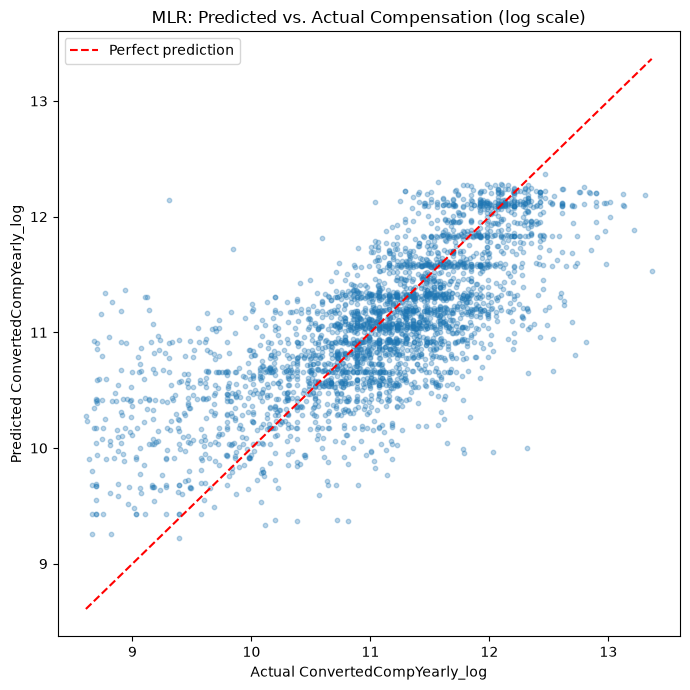

In [26]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_mlr, alpha=0.3, s=10)
lims = [min(y_test.min(), y_pred_mlr.min()), max(y_test.max(), y_pred_mlr.max())]
plt.plot(lims, lims, color='red', linestyle='--', label='Perfect prediction')
plt.xlabel('Actual ConvertedCompYearly_log')
plt.ylabel('Predicted ConvertedCompYearly_log')
plt.title('MLR: Predicted vs. Actual Compensation (log scale)')
plt.legend()
plt.tight_layout()
plt.show()


**Coefficients.** I sort all MLR coefficients by size below. This shows which
features matter most.


In [27]:
coef_table = pd.DataFrame({
    'Feature': X_mlr.columns,
    'Coefficient': mlr.coef_,
}).sort_values('Coefficient', key=abs, ascending=False).reset_index(drop=True)

coef_table


,Feature,Coefficient
0,Country_United States of America,1.544075e+00
1,Country_Canada,1.103174e+00
2,Country_United Kingdom,1.024517e+00
3,"Not employed, and not looking for work",9.857679e-01
4,Country_Germany,9.098652e-01
5,Retired,-6.698098e-01
6,Country_Poland,6.647494e-01
7,Country_France,6.638831e-01
8,Country_Other,6.302778e-01
9,Country_Spain,5.561793e-01


### 7. Summary

In [29]:
print(f"Modeling subset: {len(df_model)} respondents "
      f"(compensation reported, outliers excluded, no missing required feature)")
print(f"Train / Test split: {len(X_train_mlr)} / {len(X_test_mlr)}")
print(f"\nSLR (WorkExp only)      R2 = {slr_r2:.4f}, RMSE = {slr_rmse:.4f}")
print(f"MLR (full feature set)  R2 = {mlr_r2:.4f}, RMSE = {mlr_rmse:.4f}")
print(f"MLR MAE in dollars: ${mlr_mae_dollars:,.0f}")
print(f"\nR2 improvement from adding categorical drivers: {mlr_r2 - slr_r2:.4f}")
print(f"\nTop 5 coefficients by absolute size:")
print(coef_table.head(5).to_string(index=False))


Modeling subset: 15011 respondents (compensation reported, outliers excluded, no missing required feature)
Train / Test split: 12008 / 3003

SLR (WorkExp only)      R2 = 0.1690, RMSE = 0.7753
MLR (full feature set)  R2 = 0.5368, RMSE = 0.5788
MLR MAE in dollars: $31,535

R2 improvement from adding categorical drivers: 0.3678

Top 5 coefficients by absolute size:
                               Feature  Coefficient
      Country_United States of America     1.544075
                        Country_Canada     1.103174
                Country_United Kingdom     1.024517
Not employed, and not looking for work     0.985768
                       Country_Germany     0.909865


### Executive Summary
- **Data used:** I used 15,011 respondents, after removing missing pay, outliers, and
  rows missing a feature (64.1% of the compensation subset).
- **Models:** I compared SLR (`WorkExp` only) to MLR (all features) - both plain Linear
  Regression.
- **Result:** MLR R² = 0.537, much higher than SLR's R² = 0.169. Country, education,
  job type, and remote work explain far more of the pay gap than experience alone.
- **Biggest factors:** country has the largest effect - especially US, Canada, UK, and
  Germany (all with large positive coefficients).
- **Fixed choices:** I dropped `Age_num` and kept `WorkExp`.
- **Output:** results stay in this notebook.


Insights: Country explains pay differences much more than experience. But my model still misses almost half of the pay differences (R² = 0.537), so other things I did not use - like programming language or company size - probably matter too. I should not use this model to set exact salaries, only to compare which factors matter most.